In [1]:
#manupulação de dados em tabelas
import pandas as pd 
#plots de gráficos
import matplotlib.pyplot as plt
#manupalação de vetores
import numpy as np 

#biblioteca spacy
import spacy
#OBS: Caso não tenha o pacote em português, execute no terminal o comando: python3 -m spacy download pt

# biblioteca string - Nativa do python
import string 

#Os stop words são oriundo da biblioteca spacy
from spacy.lang.pt.stop_words import STOP_WORDS

In [2]:
pln=spacy.load("pt_core_news_sm")
stop_words=STOP_WORDS
pontuacoes=string.punctuation
pontuacoes=pontuacoes+"..."+' '

# remove da lista de stop words alguns elementos importantes
stop_words.remove('bom')
stop_words.remove('muito')
stop_words.remove('não')
stop_words.remove('nem')

In [3]:
def processamento(texto):
    # texto em minuscula
    texto=texto.lower()
    documento=pln(texto)
    
    #removendo stop words
    lista_tokens_1=[]
    for p in documento:
        if (p.text in stop_words)==False:
            lista_tokens_1.append(p)
    #removendo pontuações      
    lista_tokens_2=[]
    for p in lista_tokens_1:
        if (p.text in pontuacoes)==False:
            lista_tokens_2.append(p)
    #lematização de tokens        
    lista_tokens_3=[]
    for p in lista_tokens_2:
        lista_tokens_3.append(p.lemma_)

    return lista_tokens_3

In [12]:
df=pd.read_csv('olist_order_reviews_dataset.csv')
# Amostrado da tabela
df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [13]:
df['review_creation_date']=pd.to_datetime(df['review_creation_date'])
# encontrando o ano de publicação
ano=[]
for i in range(len(df)):
    ano.append(df['review_creation_date'].iloc[i].year)
df['ANO']=ano

# Seleção de comentários de 2018
df=df[df['ANO']==2018].reset_index(drop=True)

#remover linhas duplicadas
df.drop_duplicates(subset='review_id',inplace=True)
# selecionar apenas algumas colunas releantes
df=df[['review_comment_title','review_comment_message','review_score']].reset_index(drop=True)
# preencher campos vazios
df.fillna('',inplace=True)
# reestruturação dos comentários
df['review']=df['review_comment_title']+ ' '+df['review_comment_message']
# remoção de comentário vazios
df['review']=df['review'].replace(' ',np.nan)
df=df.dropna(subset="review").reset_index(drop=True)

In [14]:
df

,review_comment_title,review_comment_message,review_score,review
0,,Parabéns lojas lannister adorei comprar pela I...,5,Parabéns lojas lannister adorei comprar pela ...
1,recomendo,aparelho eficiente. no site a marca do aparelh...,4,recomendo aparelho eficiente. no site a marca ...
2,,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
3,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",5,"Super recomendo Vendedor confiável, produto ok..."
4,,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI ..."
...,...,...,...,...
24490,,"Produto original,prazo de entrega rápido.Super...",5,"Produto original,prazo de entrega rápido.Supe..."
24491,,Tive um problema na entrega em que o correio c...,2,Tive um problema na entrega em que o correio ...
24492,,Entregou dentro do prazo. O produto chegou em ...,5,Entregou dentro do prazo. O produto chegou em...
24493,,"O produto não foi enviado com NF, não existe v...",3,"O produto não foi enviado com NF, não existe ..."


# Vetorizar textos

In [32]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import seaborn as sns 

In [18]:
corpus=list(df['review'].values)

In [20]:
# essa etapa demora um pouco
vectorizer = CountVectorizer(tokenizer=processamento,max_features=1000,stop_words=None,token_pattern=None)
vectorizer.fit(corpus)

CountVectorizer(max_features=1000, token_pattern=None,
                tokenizer=<function processamento at 0x7f68d0d01e50>)

In [21]:
vocabulario=vectorizer.get_feature_names()

/home/jlbdearaujo/.local/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [22]:
bow=vectorizer.transform(corpus)

In [23]:
d_bow=pd.DataFrame(data=bow.toarray(),columns=vocabulario)

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [28]:
# utilizarei apenas uma amostra para treinar o modelo. 
l1=list(df[df["review_score"]==1].index)
l3=list(df[df["review_score"]==3].index)
l5=list(df[df["review_score"]==5].index)
lista=l1+l3+l5
X_bow=d_bow.loc[lista].values
y_score_bow=y=df['review_score'].loc[lista].values

In [29]:
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(X_bow, y_score_bow,test_size=0.3, random_state = 42)

clf = LogisticRegression(max_iter=10000,random_state=42).fit(X_train_bow, y_train_bow)

y_pred=clf.predict(X_test_bow)

print("Acurácia: ", accuracy_score(y_test_bow, y_pred))
print("\nF1-Score:", f1_score(y_test_bow, y_pred, average='weighted'))

Acurácia:  0.853448275862069

F1-Score: 0.8395254633029494


In [30]:
d_bow_teste=pd.DataFrame({'TESTE':y_test_bow,'PRED':y_pred})
d_bow_teste

,TESTE,PRED
0,5,3
1,5,5
2,5,5
3,1,1
4,5,5
...,...,...
5911,5,5
5912,1,1
5913,5,5
5914,1,1


Text(137.16666666666669, 0.5, 'real')

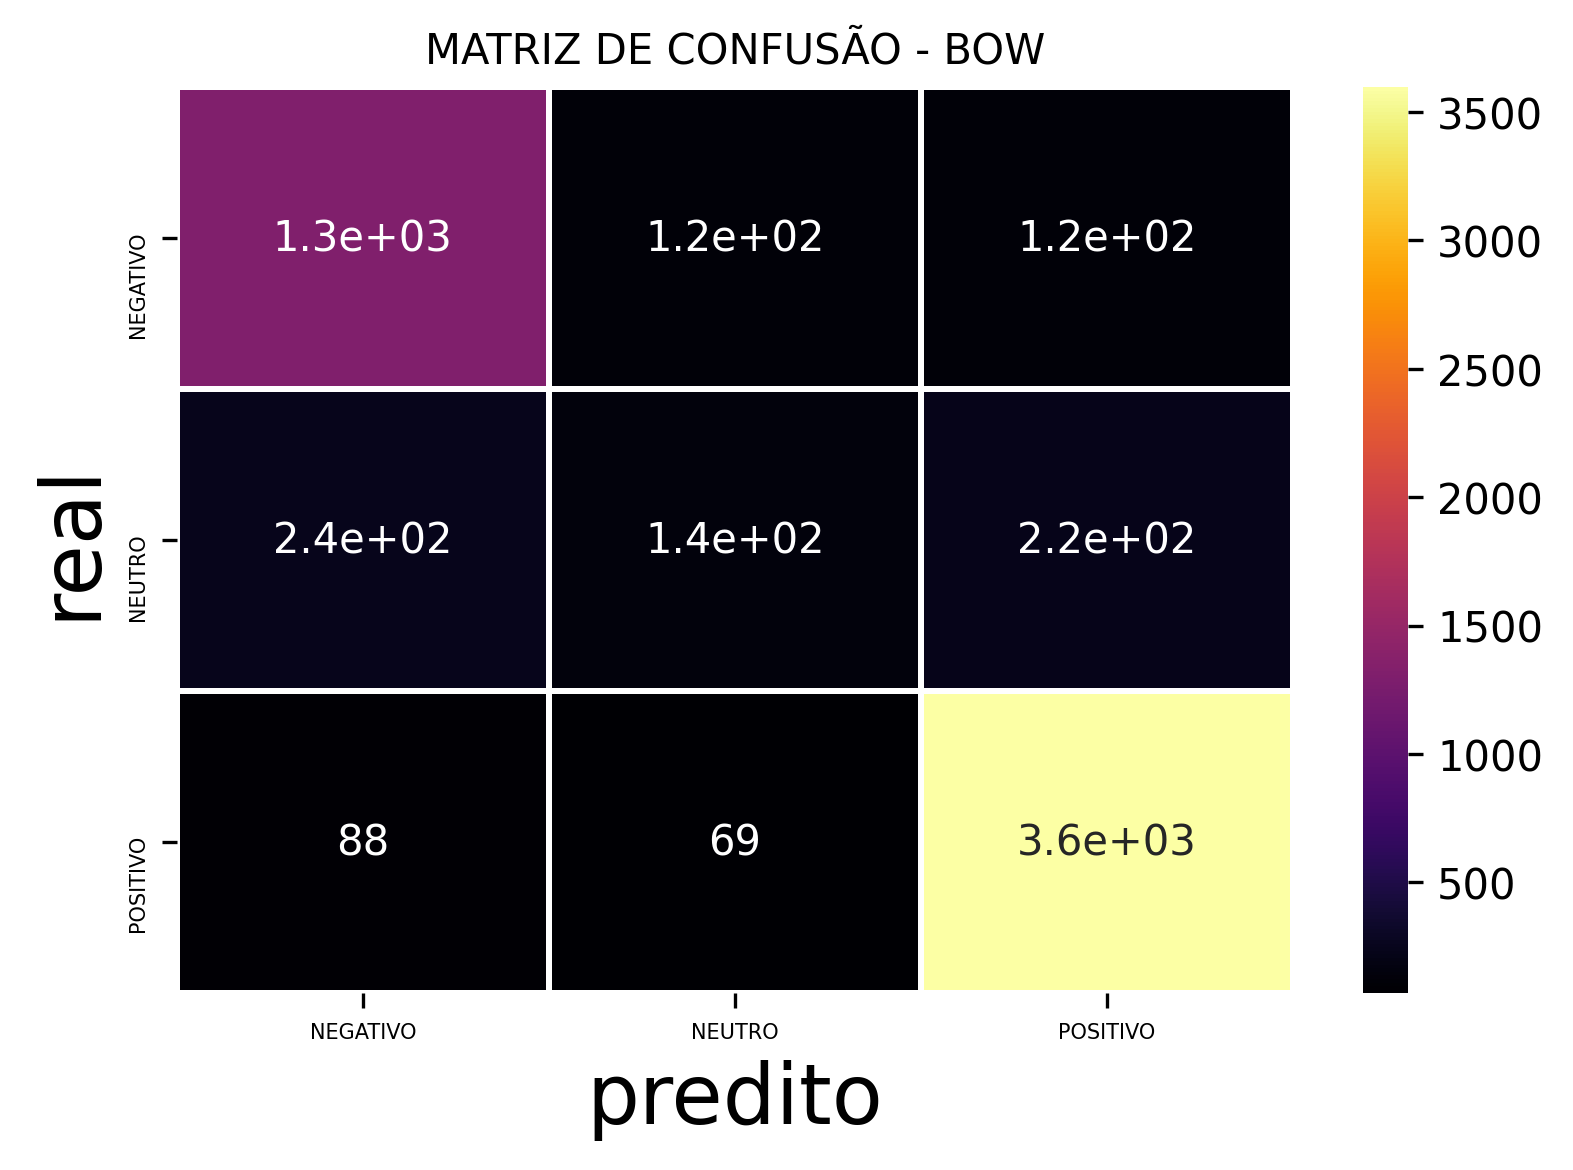

In [33]:
plt.figure(dpi=300)
plt.title('MATRIZ DE CONFUSÃO - BOW',fontsize=10)
sns.heatmap(confusion_matrix(d_bow_teste['TESTE'],d_bow_teste['PRED']),annot=True,cmap='inferno',lw=1,annot_kws={"size":10})
plt.xticks([0.5,1.5,2.5],['NEGATIVO',"NEUTRO",'POSITIVO'],fontsize=5)
plt.yticks([0.5,1.5,2.5],['NEGATIVO',"NEUTRO",'POSITIVO'],fontsize=5)
plt.xlabel('predito',fontsize=20)
plt.ylabel('real',fontsize=20)